<a href="https://colab.research.google.com/github/miirage-exe/data-driven-engineering/blob/main/topic_2_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering

In [40]:
# COLAB SETUP - (generated by Claude). Allows different members of the project to run the code in google colab.
# This code snippet copies our project's github repo to the google colab environment.
import os, sys
if 'google.colab' in sys.modules:
    os.chdir('/content/')
    if os.path.exists('data-driven-engineering'):
        !rm -rf data-driven-engineering
    !git clone https://github.com/miirage-exe/data-driven-engineering.git
    os.chdir('/content/data-driven-engineering')

Cloning into 'data-driven-engineering'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 141 (delta 49), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 11.49 MiB | 12.55 MiB/s, done.
Resolving deltas: 100% (49/49), done.


In [41]:
df = pd.read_csv("data/topic_2/Variable Re/Re_variable.csv")

df.head()

,airfoil,Reynolds,alpha,CL,CD
0,NACA 0010,25000,0.0,-0.0000,0.02381
1,NACA 0010,25000,0.1,0.0039,0.02382
2,NACA 0010,25000,0.2,0.0077,0.02383
3,NACA 0010,25000,0.3,0.0116,0.02386
4,NACA 0010,25000,0.4,0.0154,0.02389


# Data visualization

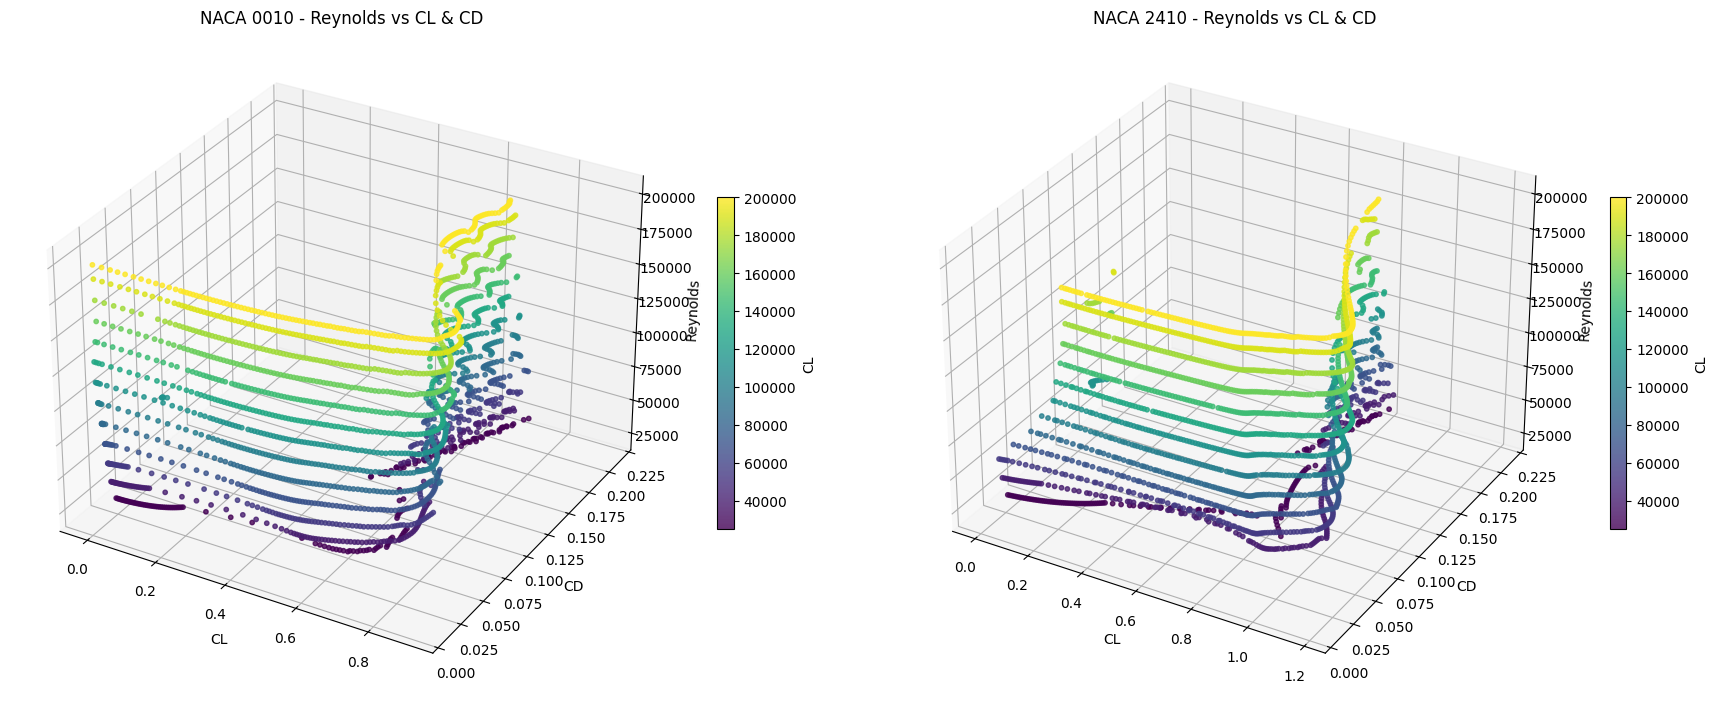

In [42]:
fig = plt.figure(figsize=(18, 7))

for i, naca in enumerate(["NACA 0010", "NACA 2410"]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    df_unique_naca = df[df.airfoil == naca]

    scatter = ax.scatter(
        df_unique_naca['CL'],
        df_unique_naca['CD'],
        df_unique_naca['Reynolds'],
        c=df_unique_naca['Reynolds'],
        cmap='viridis',
        s=10,
        alpha=0.8
    )

    ax.set_xlabel('CL')
    ax.set_ylabel('CD')
    ax.set_zlabel('Reynolds')
    ax.set_title(f'{naca} - Reynolds vs CL & CD')

    fig.colorbar(scatter, ax=ax, label='CL', shrink=0.5)

plt.tight_layout()
plt.show()

## Observations
As we can see in the plots, the impact of Reynolds and the NACA shape on the Cl and Cd coefficients is not linear. Since we cannot easily make a valid hypothesis on the function's form between Reynolds, alpha, Cd and Cl, we decided to use a Neural Network, wich allows us to approximate the function without knowing its shape.

# Outliers identification and Data cleaning (clustering)

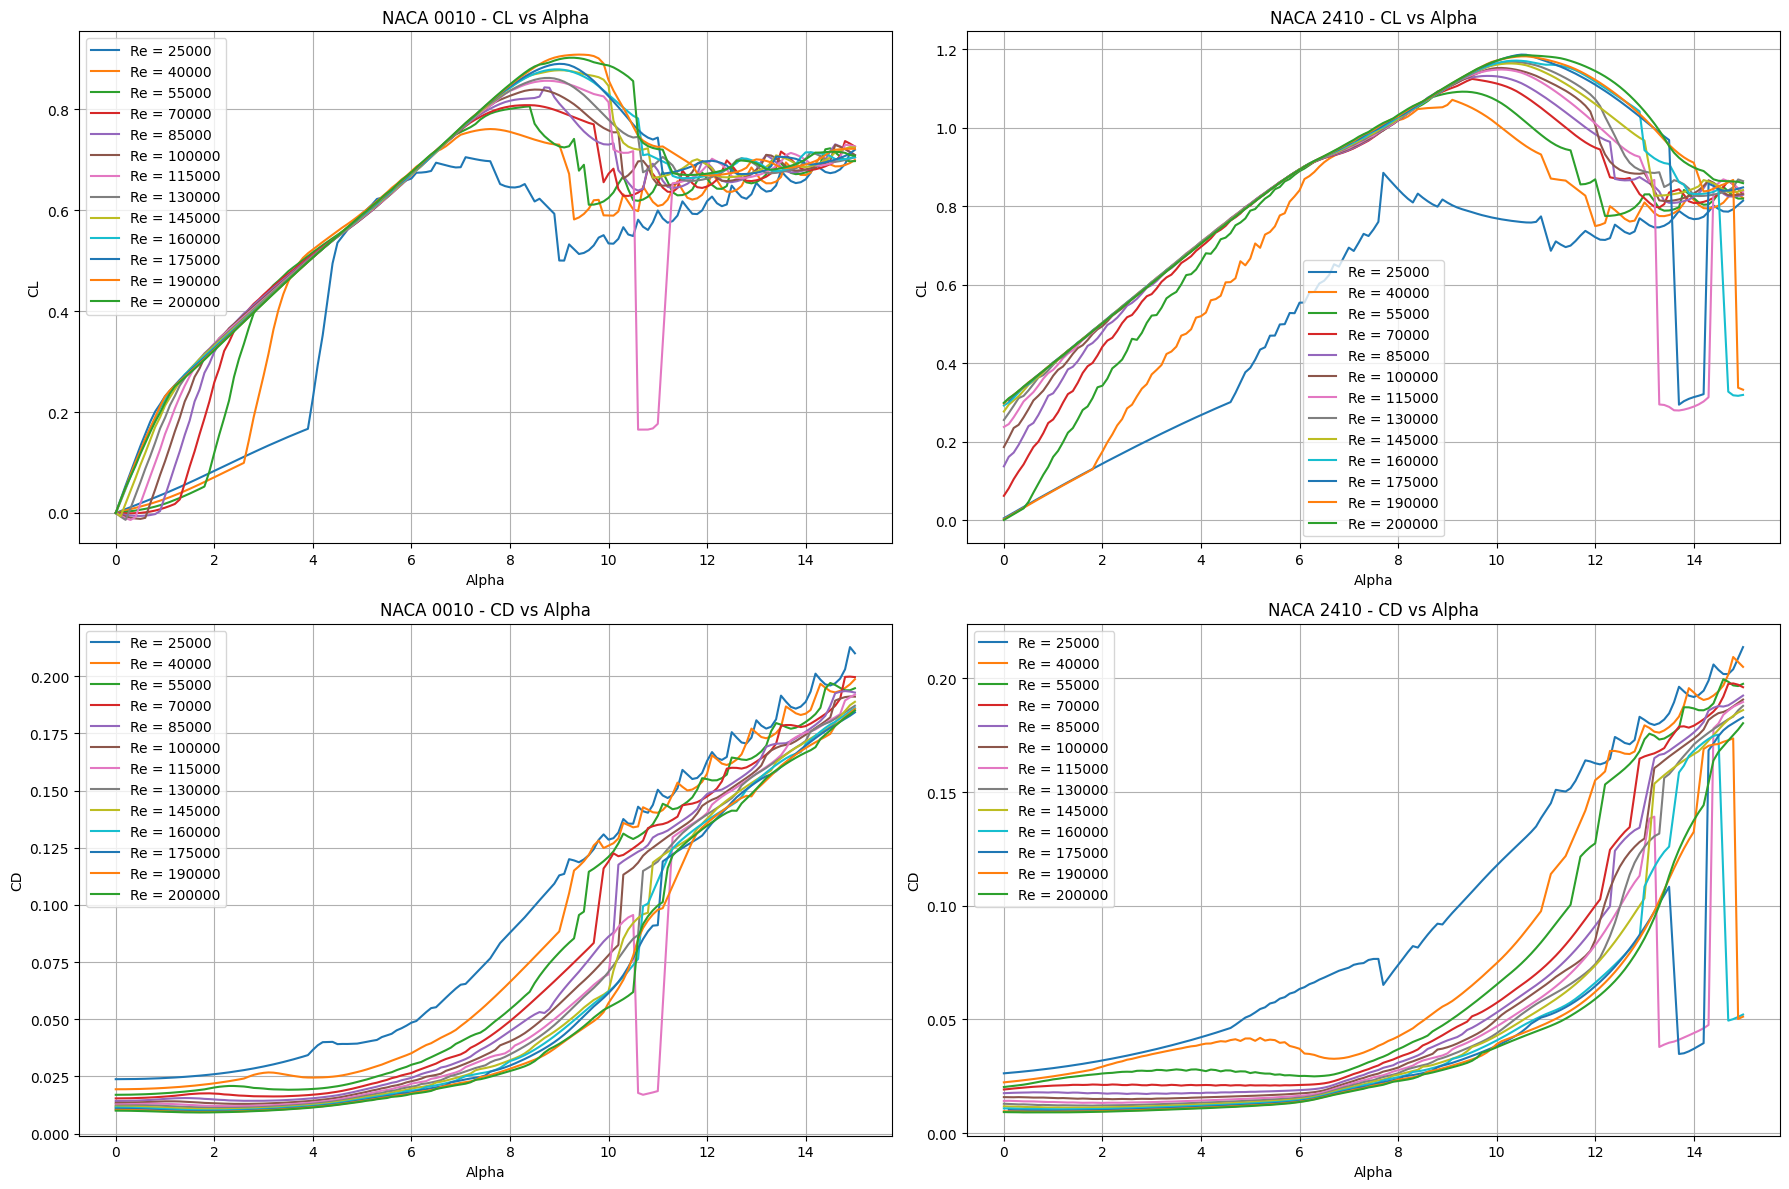

In [43]:
def plot_2d(threshold_cl_fn=None, threshold_cd_fn=None):
  fig, axes = plt.subplots(2, 2, figsize=(18, 12))
  nacas = ["NACA 0010", "NACA 2410"]

  for col, naca in enumerate(nacas):
      df_naca = df[df.airfoil == naca]
      alpha_full = df_naca['alpha'].sort_values()

      # --- Top row: CL vs Alpha ---
      ax_cl = axes[0, col]
      for re, group in df_naca.groupby('Reynolds'):
          group_sorted = group.sort_values('alpha')
          ax_cl.plot(group_sorted['alpha'], group_sorted['CL'], label=f'Re = {re:.0f}')

      if threshold_cl_fn:
          ax_cl.plot(alpha_full, threshold_cl_fn(alpha_full),
                      label='CL Threshold', color='black', linestyle='--', linewidth=2)
      ax_cl.set_xlabel('Alpha')
      ax_cl.set_ylabel('CL')
      ax_cl.set_title(f'{naca} - CL vs Alpha')
      ax_cl.legend()
      ax_cl.grid(True)

      # --- Bottom row: CD vs Alpha ---
      ax_cd = axes[1, col]
      for re, group in df_naca.groupby('Reynolds'):
          group_sorted = group.sort_values('alpha')
          ax_cd.plot(group_sorted['alpha'], group_sorted['CD'], label=f'Re = {re:.0f}')

      if threshold_cd_fn:
          ax_cd.plot(alpha_full, threshold_cd_fn(alpha_full),
                      label='CD Threshold', color='black', linestyle='--', linewidth=2)
      ax_cd.set_xlabel('Alpha')
      ax_cd.set_ylabel('CD')
      ax_cd.set_title(f'{naca} - CD vs Alpha')
      ax_cd.legend()
      ax_cd.grid(True)

  plt.tight_layout()
  plt.show()


plot_2d(None)

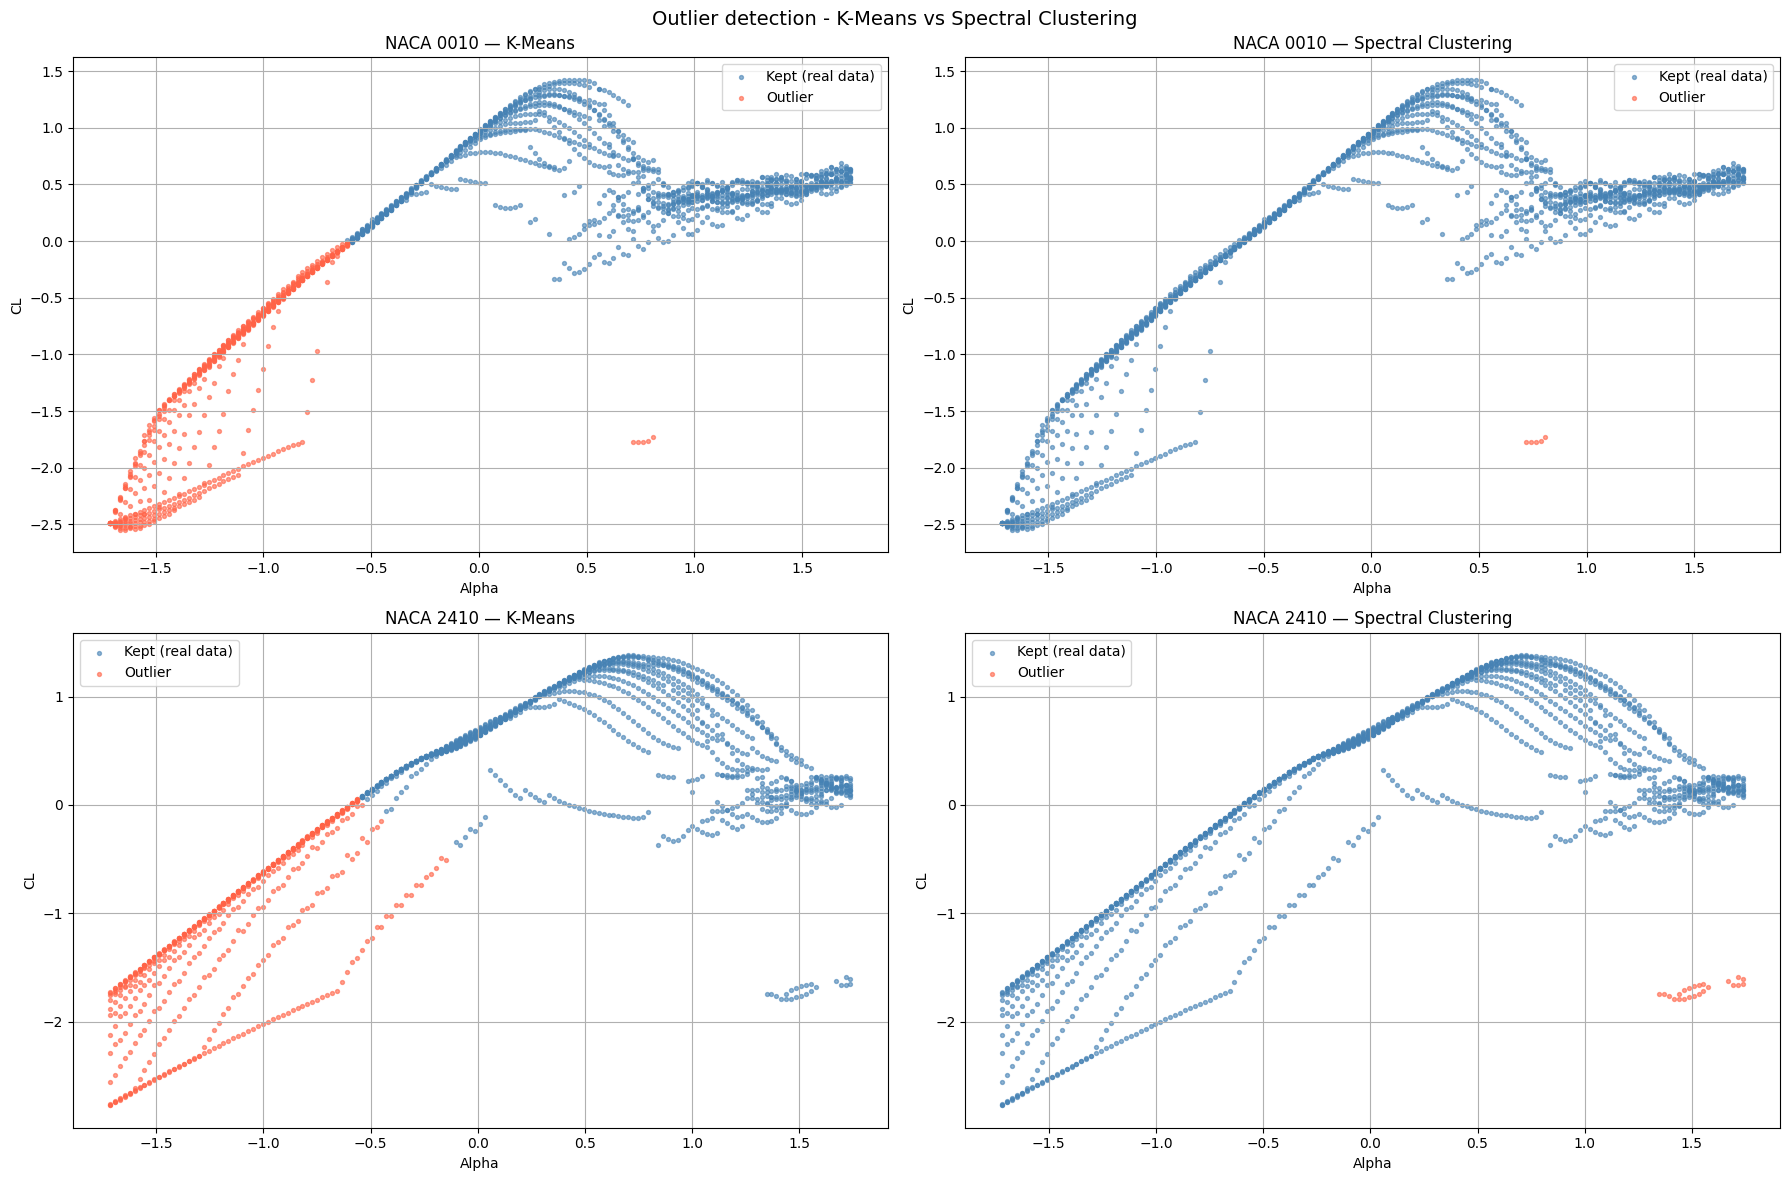

In [44]:
# We cluster in (alpha, CL) space with k=2: "real data" vs "outliers"

nacas = ["NACA 0010", "NACA 2410"]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

kmean_clustering = KMeans(n_clusters=2, random_state=42, n_init=10)
spectral_clustering = SpectralClustering(n_clusters=2, random_state=42, affinity='rbf', gamma=4) # gamma=1 (default) does not work. Only works with gamma >= 3

for row, naca in enumerate(nacas):

    df_naca  = df[df['airfoil'] == naca]
    X_cl     = df_naca[['alpha', 'CL']].values   # 2-D feature space for clustering

    # We need to scale the data cause otherwise CL and CD have much smaller value leading the clustering algorithm to separate around CL only (ie. vertically)
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(X_cl)  # zero mean, unit variance on each axis

    # --- K-Means ---
    km_labels = kmean_clustering.fit_predict(X_scaled)
    # "real" cluster = the one with the higher mean CL
    km_main   = np.argmax([X_cl[km_labels == 0, 1].mean(),
                           X_cl[km_labels == 1, 1].mean()])

    # --- Spectral Clustering ---
    sc_labels = spectral_clustering.fit_predict(X_scaled)
    sc_main   = np.argmax([X_cl[sc_labels == 0, 1].mean(),
                           X_cl[sc_labels == 1, 1].mean()])

    # --- Plots ---
    for col, (labels, main, title) in enumerate([
        (km_labels, km_main, "K-Means"),
        (sc_labels, sc_main, "Spectral Clustering"),
    ]):
        ax = axes[row, col]
        ax.scatter(X_scaled[labels == main,  0], X_scaled[labels == main,  1],
                   c='steelblue', s=8, alpha=0.6, label='Kept (real data)')
        ax.scatter(X_scaled[labels != main,  0], X_scaled[labels != main,  1],
                   c='tomato',    s=8, alpha=0.6, label='Outlier')
        ax.set_title(f'{naca} — {title}')
        ax.set_xlabel('Alpha')
        ax.set_ylabel('CL')
        ax.legend()
        ax.grid(True)

plt.suptitle('Outlier detection - K-Means vs Spectral Clustering', fontsize=14)
plt.tight_layout()
plt.show()

Spectral Clustering outperforms K-Means in this case because the two groups are not compact blobs but elongated curves, a structure that Spectral Clustering is designed to capture better.

Rows kept after clustering (spectral): 3831


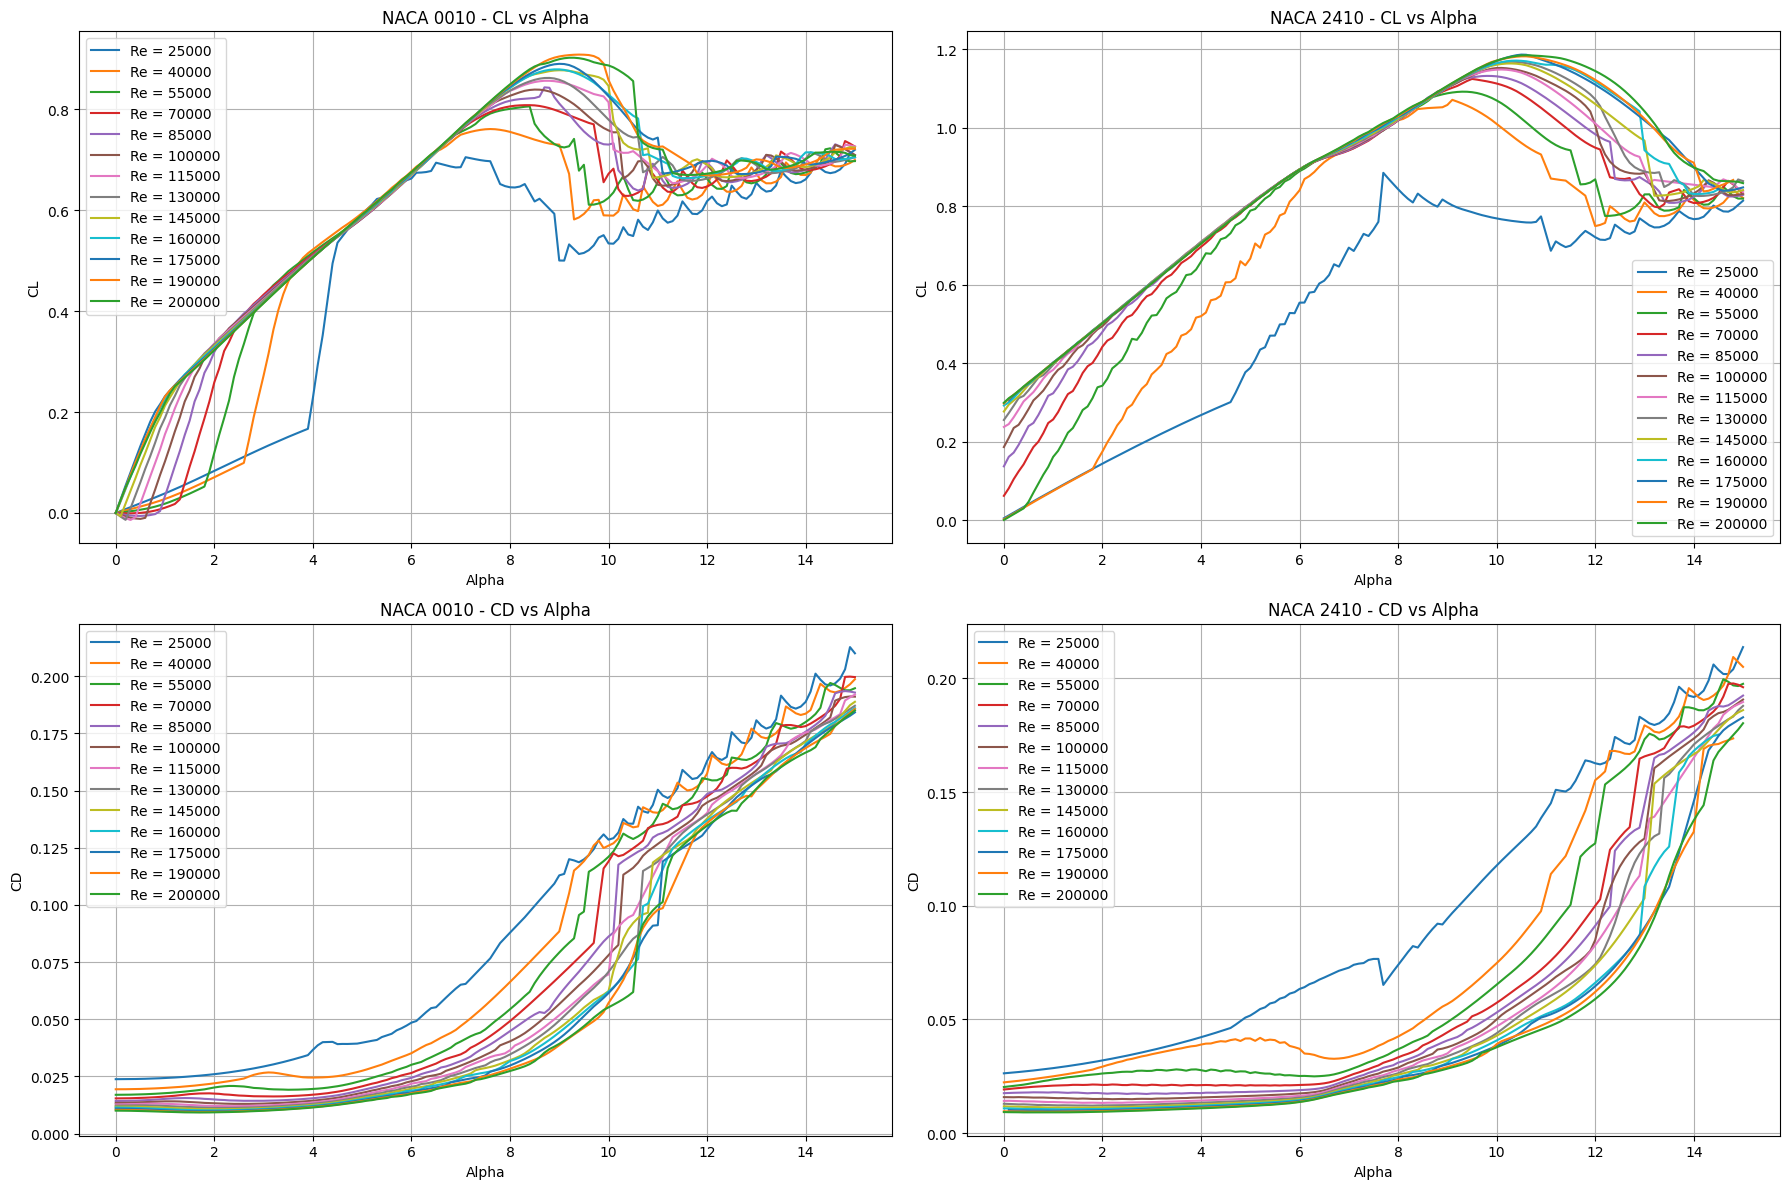

In [45]:
# Apply chosen clustering method to filter df

method = 'spectral'   # <- we selected SpectralClustering method

kept_indices = []

for naca in df['airfoil'].unique():
    df_naca  = df[df['airfoil'] == naca]
    X_cl     = df_naca[['alpha', 'CL']].values

    # Same as before, we scale before doing the clustering
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(X_cl)  # zero mean, unit variance on each axis

    if method == 'kmeans':
        labels    = kmean_clustering.fit_predict(X_scaled)
    else:
        labels    = spectral_clustering.fit_predict(X_scaled)

    main_cluster = np.argmax([X_cl[labels == 0, 1].mean(),
                              X_cl[labels == 1, 1].mean()])
    kept_indices.extend(df_naca.index[labels == main_cluster].tolist())

df = df.loc[kept_indices]
print(f"Rows kept after clustering ({method}): {len(df)}")

plot_2d()   # plot the data to sanity-check the result

# Hidding some reynolds

To test whether the model can predict results for Reynolds numbers it has never seen during training, we remove three values (55,000, 115,000 and 190,000) from the dataset and store them separately in `df_unseen`. The model is then trained without these values, and we use them at the end to check how well it generalizes.

In [46]:

mask = df['Reynolds'].isin([190000,115000, 55000])
df_unseen = df[mask] #has only 190 000, 115 000 and 55 000
df = df[~mask] #used for training and testing without those 3 Reynolds numbers


# Feature Extraction
The `airfoil` feature encodes airfoil geometry as a NACA identifier (in our case `NACA 0010` and `NACA 2410`).
To make this information accessible to the model, we decompose it into explicit numerical features representing its physical parameters (camber, camber position, thickness).

In [47]:
def parse_naca4(naca_str):
    """
    Parse a NACA 4-digit airfoil code and return its geometric parameters.

    Parameters:
        naca_str (str): e.g. "NACA 0010", "NACA 2410", "0010", "2410"

    Reads:
        - max_camber     : as % of chord (e.g. 2 means 2%)
        - camber_position: position of max camber in tenths of chord
        - thickness      : as % of chord
    """
    code = naca_str.upper().replace("NACA", "").strip()

    if len(code) != 4 or not code.isdigit():
        raise ValueError(f"Expected a 4-digit NACA code, got: '{naca_str}'")

    max_camber      = int(code[0]) / 100   #devide by 100 to not have a percentage
    camber_position = int(code[1]) / 10    # position is a tenth of the chord
    thickness       = int(code[2:]) / 100

    return pd.Series([max_camber, camber_position, thickness])
df[['max_camber', 'camber_position', 'thickness']] = df['airfoil'].apply(parse_naca4)
df_unseen[['max_camber', 'camber_position', 'thickness']] = df_unseen['airfoil'].apply(parse_naca4)
df.head(10)

# test_cases = ["NACA 0010", "NACA 2410", "NACA 0006", "NACA 2420"]
# for naca in test_cases:
#     result = parse_naca4(naca)
#     print(f"{naca}  →  max_camber={result[0]}, camber_pos={result[1]}0 chord, thickness={result[2]}")


,airfoil,Reynolds,alpha,CL,CD,max_camber,camber_position,thickness
0,NACA 0010,25000,0.0,-0.0000,0.02381,0.0,0.0,0.1
1,NACA 0010,25000,0.1,0.0039,0.02382,0.0,0.0,0.1
2,NACA 0010,25000,0.2,0.0077,0.02383,0.0,0.0,0.1
3,NACA 0010,25000,0.3,0.0116,0.02386,0.0,0.0,0.1
4,NACA 0010,25000,0.4,0.0154,0.02389,0.0,0.0,0.1
5,NACA 0010,25000,0.5,0.0192,0.02393,0.0,0.0,0.1
6,NACA 0010,25000,0.6,0.0230,0.02399,0.0,0.0,0.1
7,NACA 0010,25000,0.7,0.0268,0.02406,0.0,0.0,0.1
8,NACA 0010,25000,0.8,0.0308,0.02413,0.0,0.0,0.1
9,NACA 0010,25000,0.9,0.0348,0.02422,0.0,0.0,0.1


#Creating the neural network

In [48]:
class MyNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_hidden_layers):
        super().__init__()
        layers = []

        # Input → first hidden
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())

        # Remaining hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        # Last hidden → output (no activation on output)
        layers.append(nn.Linear(hidden_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [49]:
# Input
X = df[['max_camber', 'camber_position', 'thickness', 'Reynolds', 'alpha']].values

# Output
Y = df[['CL', 'CD']].values

# Splitting between training and testing sets

Train: 2069, Test: 888


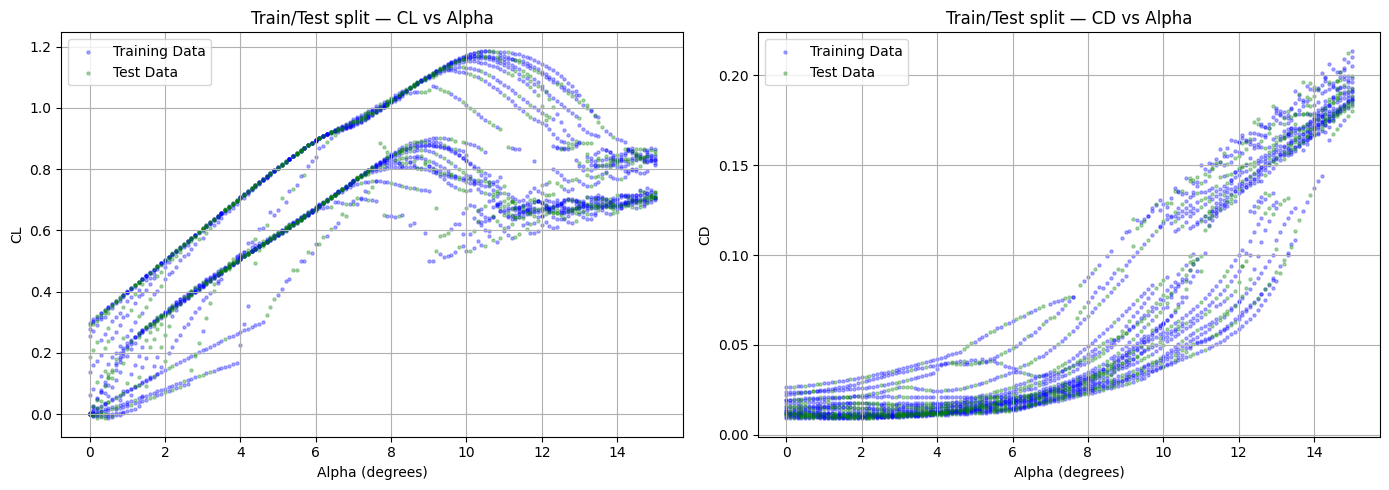

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CL
axes[0].scatter(X_train[:, 4], Y_train[:, 0], c='b', alpha=0.3, s=5, label='Training Data')
axes[0].scatter(X_test[:, 4],  Y_test[:, 0],  c='g', alpha=0.3, s=5, label='Test Data')
axes[0].set_xlabel('Alpha (degrees)')
axes[0].set_ylabel('CL')
axes[0].set_title('Train/Test split — CL vs Alpha')
axes[0].legend()
axes[0].grid(True)

# CD
axes[1].scatter(X_train[:, 4], Y_train[:, 1], c='b', alpha=0.3, s=5, label='Training Data')
axes[1].scatter(X_test[:, 4],  Y_test[:, 1],  c='g', alpha=0.3, s=5, label='Test Data')
axes[1].set_xlabel('Alpha (degrees)')
axes[1].set_ylabel('CD')
axes[1].set_title('Train/Test split — CD vs Alpha')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Scaling data

In [51]:
# Scale based on TRAINING data only
def scale(X, Xmin, Xmax):
    denom = Xmax - Xmin
    denom = torch.where(denom == 0, torch.ones_like(denom), denom)
    return 2 * (X - Xmin) / denom - 1


X_min, X_max = X_train_t.min(dim=0).values, X_train_t.max(dim=0).values
Y_min, Y_max = Y_train_t.min(dim=0).values, Y_train_t.max(dim=0).values

X_train_s = scale(X_train_t, X_min, X_max)
X_test_s  = scale(X_test_t,  X_min, X_max)
Y_train_s = scale(Y_train_t, Y_min, Y_max)
Y_test_s  = scale(Y_test_t,  Y_min, Y_max)

# Different def scale than in the excersices since the collumn of thickness caused an issue (giving 0 everywhere)
#Check up of the code to see if we have any "NAN" output
#print("X_min:", X_min)
# print("X_max:", X_max)
# print("Difference (should not be 0):", X_max - X_min)
print("\nAny nan in X_train_s?", torch.isnan(X_train_s).any().item())
print("Any nan in Y_train_s?", torch.isnan(Y_train_s).any().item())

print(X_train_s)
print(X_test_s)


Any nan in X_train_s? False
Any nan in Y_train_s? False
tensor([[ 1.0000,  1.0000, -1.0000,  0.3714,  0.4000],
        [ 1.0000,  1.0000, -1.0000, -0.8286, -1.0000],
        [-1.0000, -1.0000, -1.0000,  0.3714,  0.8800],
        ...,
        [-1.0000, -1.0000, -1.0000,  0.5429,  0.1733],
        [-1.0000, -1.0000, -1.0000,  0.7143,  0.4000],
        [-1.0000, -1.0000, -1.0000,  0.2000,  0.5200]])
tensor([[-1.0000, -1.0000, -1.0000,  0.5429, -0.4400],
        [ 1.0000,  1.0000, -1.0000,  0.3714, -0.5600],
        [ 1.0000,  1.0000, -1.0000, -0.3143, -0.6800],
        ...,
        [ 1.0000,  1.0000, -1.0000,  0.3714, -0.2667],
        [-1.0000, -1.0000, -1.0000, -0.1429, -0.3067],
        [-1.0000, -1.0000, -1.0000,  1.0000,  0.1200]])


# Construction and training of the model

In [52]:
torch.manual_seed(42)

lambda_reg = 0.00008
input_size = X_train_s.shape[1] # Explicitely link the number of input to the number of features
hidden_size = 32  #number of neurons per hidden layer
output_size = 2
num_hidden_layers = 3

model = MyNeuralNetwork(input_size, hidden_size, output_size, num_hidden_layers)
print(model)
criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=200)

MyNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


Epoch [500/10000], Train: 0.0174, Val: 0.0174
Epoch [1000/10000], Train: 0.0133, Val: 0.0135
Epoch [1500/10000], Train: 0.0107, Val: 0.0108
Epoch [2000/10000], Train: 0.0087, Val: 0.0089
Epoch [2500/10000], Train: 0.0074, Val: 0.0076
Epoch [3000/10000], Train: 0.0064, Val: 0.0066
Epoch [3500/10000], Train: 0.0057, Val: 0.0059
Epoch [4000/10000], Train: 0.0052, Val: 0.0054
Epoch [4500/10000], Train: 0.0048, Val: 0.0050
Epoch [5000/10000], Train: 0.0045, Val: 0.0047
Epoch [5500/10000], Train: 0.0043, Val: 0.0045
Epoch [6000/10000], Train: 0.0041, Val: 0.0044
Epoch [6500/10000], Train: 0.0040, Val: 0.0043
Epoch [7000/10000], Train: 0.0040, Val: 0.0042
Epoch [7500/10000], Train: 0.0039, Val: 0.0042
Epoch [8000/10000], Train: 0.0039, Val: 0.0041
Epoch [8500/10000], Train: 0.0039, Val: 0.0041
Epoch [9000/10000], Train: 0.0039, Val: 0.0041
Epoch [9500/10000], Train: 0.0039, Val: 0.0041
Epoch [10000/10000], Train: 0.0039, Val: 0.0041

Best validation loss: 0.0041


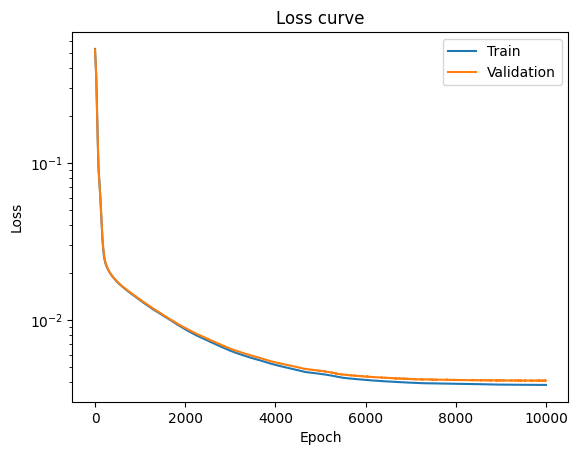

In [53]:
# neural network + L1 regularisation

train_loss_list = []
test_loss_list  = []
num_epochs      = 10000

# Early stopping settings
best_val_loss      = float('inf')
patience           = 500
epochs_no_improve  = 0
best_model_weights = None

for epoch in range(num_epochs):

    output = model(X_train_s)
    loss = criterion(output, Y_train_s)

    l1 = sum(torch.norm(p, 1) for p in model.parameters())
    loss_total = loss + lambda_reg * l1

    with torch.no_grad():
        output_test = model(X_test_s)
        loss_test = criterion(output_test, Y_test_s) + lambda_reg * l1

    optimiser.zero_grad()
    loss_total.backward()
    optimiser.step()

    train_loss_list.append(loss_total.item())
    test_loss_list.append(loss_test.item())

    # Early stopping check
    if loss_test.item() < best_val_loss:
        best_val_loss  = loss_test.item()
        epochs_no_improve = 0
        best_model_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        model.load_state_dict(best_model_weights)
        break

    scheduler.step(loss_test.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train: {loss_total.item():.4f}, Val: {loss_test.item():.4f}")

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

print(f"\nBest validation loss: {best_val_loss:.4f}")

# Plot loss curve
plt.plot(train_loss_list, label='Train')
plt.plot(test_loss_list,  label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title('Loss curve')
plt.show()

# Visualization of the model results

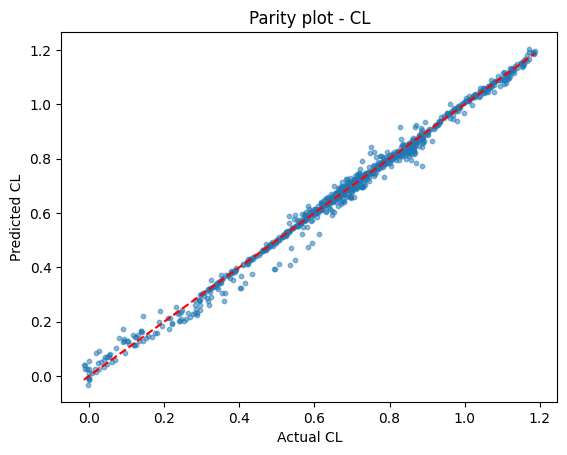

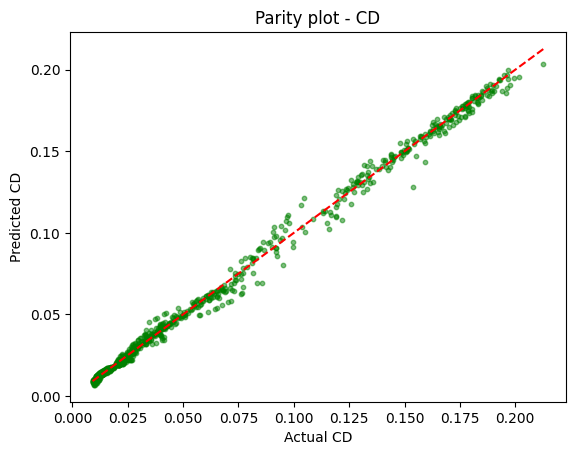

In [54]:
def unscale(X_scaled, Xmin, Xmax):
    denom = Xmax - Xmin
    denom = torch.where(denom == 0, torch.ones_like(denom), denom)
    return (X_scaled + 1) / 2 * denom + Xmin

with torch.no_grad():
    Y_pred_s = model(X_test_s)
    Y_pred = unscale(Y_pred_s, Y_min, Y_max)
    Y_actual = unscale(Y_test_s, Y_min, Y_max)

# Parity plot for CL
plt.scatter(Y_actual[:, 0], Y_pred[:, 0], alpha=0.5, s=10)
plt.plot([Y_actual[:, 0].min(), Y_actual[:, 0].max()],
         [Y_actual[:, 0].min(), Y_actual[:, 0].max()], 'r--')
plt.xlabel('Actual CL'); plt.ylabel('Predicted CL')
plt.title('Parity plot - CL'); plt.show()

# Parity plot for CD
plt.scatter(Y_actual[:, 1], Y_pred[:, 1], alpha=0.5, s=10, color='green')
plt.plot([Y_actual[:, 1].min(), Y_actual[:, 1].max()],
         [Y_actual[:, 1].min(), Y_actual[:, 1].max()], 'r--')
plt.xlabel('Actual CD'); plt.ylabel('Predicted CD')
plt.title('Parity plot - CD'); plt.show()

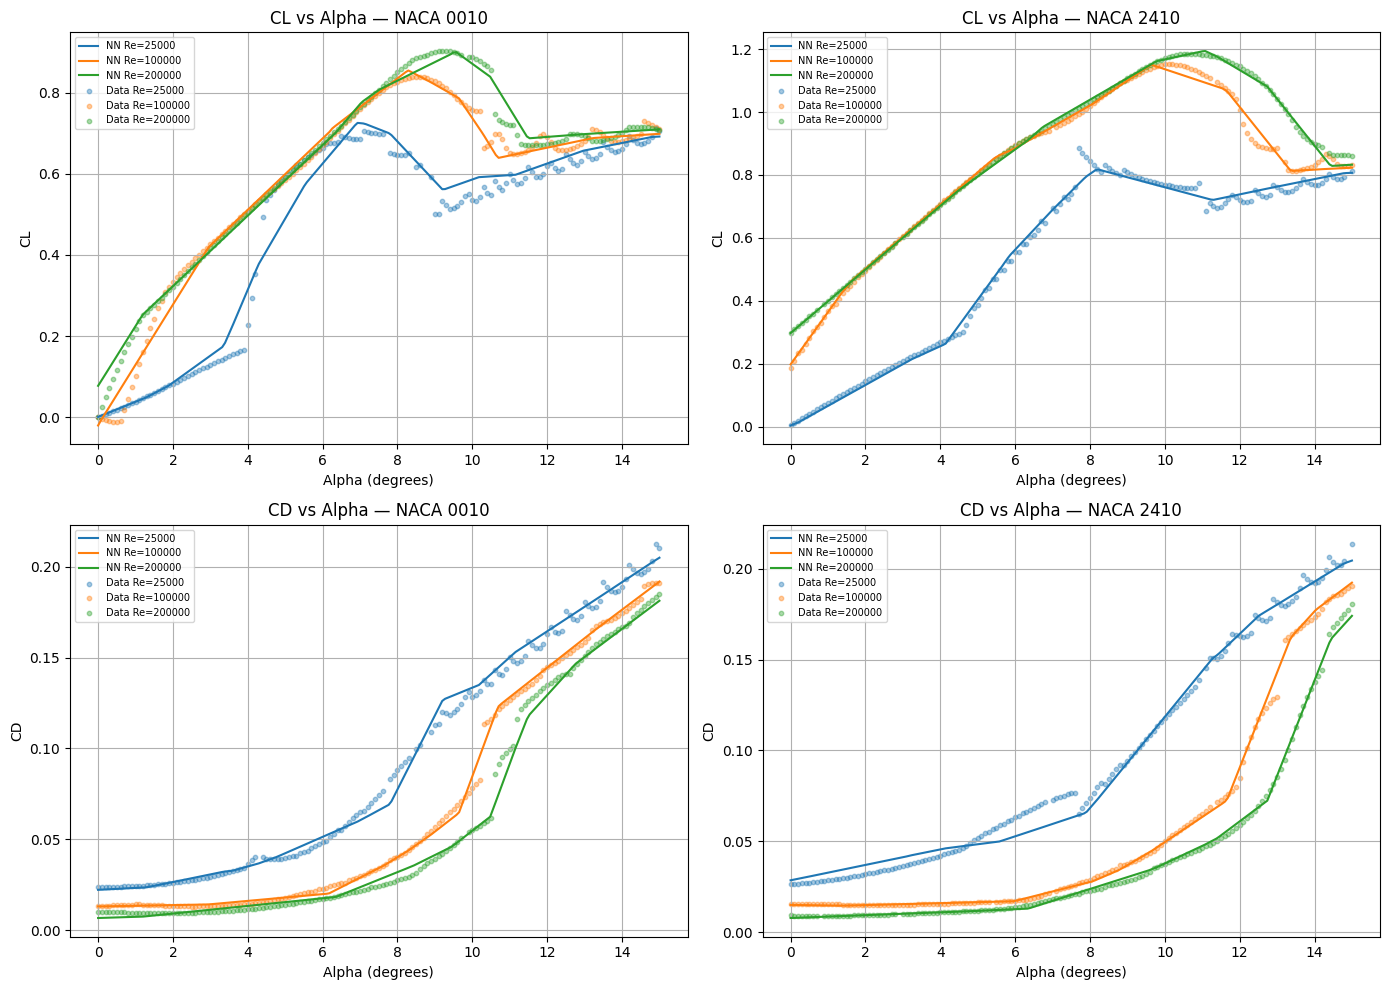

In [55]:
# Visualisation of NN predictions vs actual data

re_values = [25000, 100000, 200000]
airfoils  = ['NACA 0010', 'NACA 2410']
alpha_range = torch.linspace(0, 15, 200)  # smooth alpha sweep for plotting

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, airfoil in enumerate(airfoils):
    geom = parse_naca4(airfoil)  # returns [max_camber, camber_pos, thickness]

    for re in re_values:
        n = len(alpha_range)
        X_plot = torch.zeros(n, 5)
        X_plot[:, 0] = geom[0]           # max_camber
        X_plot[:, 1] = geom[1]           # camber_position
        X_plot[:, 2] = geom[2]           # thickness
        X_plot[:, 3] = re                # Reynolds
        X_plot[:, 4] = alpha_range       # alpha sweep

        X_plot_s = scale(X_plot, X_min, X_max)
        with torch.no_grad():
            Y_plot_s = model(X_plot_s)
            Y_plot   = unscale(Y_plot_s, Y_min, Y_max)
        axes[0, col].plot(alpha_range, Y_plot[:, 0], label=f'NN Re={re:.0f}')
        axes[1, col].plot(alpha_range, Y_plot[:, 1], label=f'NN Re={re:.0f}')

    df_foil = df[df['airfoil'] == airfoil]
    for re in re_values:
        df_re = df_foil[df_foil['Reynolds'] == re].sort_values('alpha')
        axes[0, col].scatter(df_re['alpha'], df_re['CL'], s=10, alpha=0.4, label=f'Data Re={re:.0f}')
        axes[1, col].scatter(df_re['alpha'], df_re['CD'], s=10, alpha=0.4, label=f'Data Re={re:.0f}')

    axes[0, col].set_title(f'CL vs Alpha — {airfoil}')
    axes[0, col].set_xlabel('Alpha (degrees)')
    axes[0, col].set_ylabel('CL')
    axes[0, col].legend(fontsize=7)
    axes[0, col].grid(True)

    axes[1, col].set_title(f'CD vs Alpha — {airfoil}')
    axes[1, col].set_xlabel('Alpha (degrees)')
    axes[1, col].set_ylabel('CD')
    axes[1, col].legend(fontsize=7)
    axes[1, col].grid(True)

plt.tight_layout()
plt.show()

#Quality assesment and error calculations

In this section, we evaluated the prediction error using several metrics to assess the quality of the estimated lift and drag coefficients. The error analysis was conducted over two distinct regions: pre-stall and post-stall, to capture the model's performance under the impact of stall. Additionally, the network was used to predict the behavior of Cl and Cd at Reynolds numbers that were not included in the original dataset.

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_by_region(df_actual, Y_pred_np, stall_angle):
    """
    Compute MAE, MSE, R2 separately for pre-stall and post-stall regions.
    stall_angle: approximate alpha where stall begins (tune per airfoil/Re)
    """
    alpha = df_actual['alpha'].values

    pre_stall  = alpha <= stall_angle
    post_stall = alpha >  stall_angle

    results = {}
    for region, mask in [('Pre-stall', pre_stall), ('Post-stall', post_stall)]:
        y_true_cl = df_actual['CL'].values[mask]
        y_true_cd = df_actual['CD'].values[mask]
        y_pred_cl = Y_pred_np[mask, 0]
        y_pred_cd = Y_pred_np[mask, 1]

        results[region] = {
            'MAE_CL':  mean_absolute_error(y_true_cl, y_pred_cl),
            'MSE_CL':  mean_squared_error(y_true_cl,  y_pred_cl),
            'R2_CL':   r2_score(y_true_cl,            y_pred_cl),
            'MAE_CD':  mean_absolute_error(y_true_cd, y_pred_cd),
            'MSE_CD':  mean_squared_error(y_true_cd,  y_pred_cd),
            'R2_CD':   r2_score(y_true_cd,            y_pred_cd),
        }

    return results

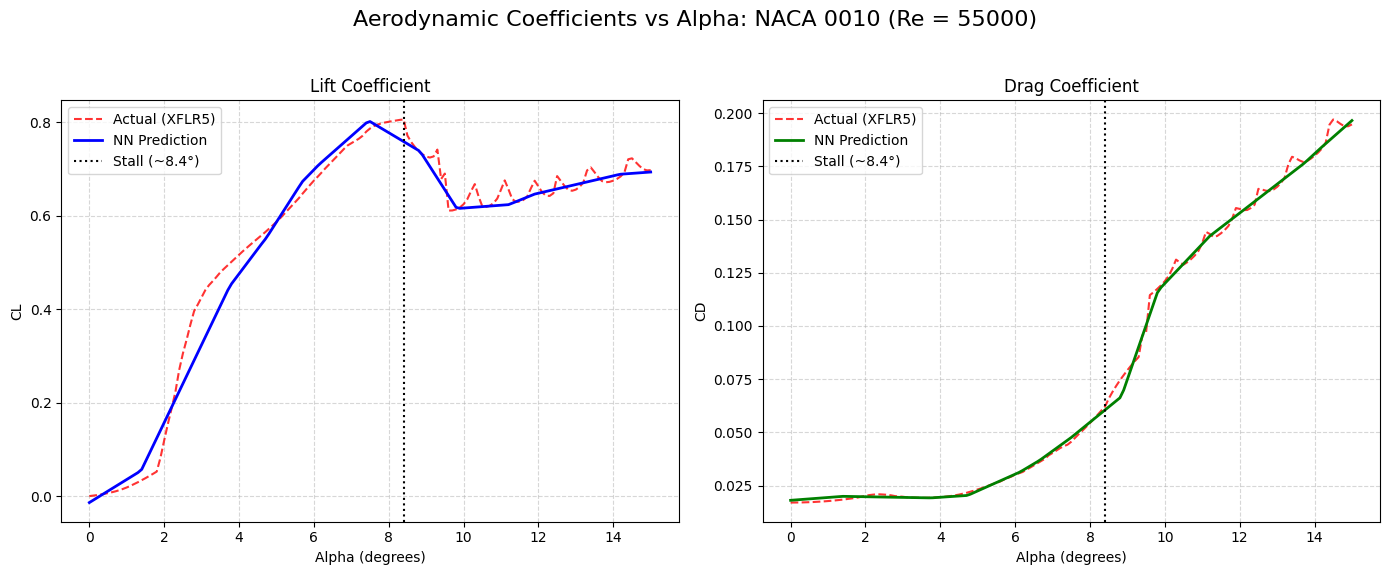


NACA 0010 | Re = 55000
  Pre-stall:
    CL → MAE: 0.0313, MSE: 0.0017, R²: 0.9789
    CD → MAE: 0.0008, MSE: 0.0000, R²: 0.9932
  Post-stall:
    CL → MAE: 0.0146, MSE: 0.0004, R²: 0.7359
    CD → MAE: 0.0027, MSE: 0.0000, R²: 0.9904


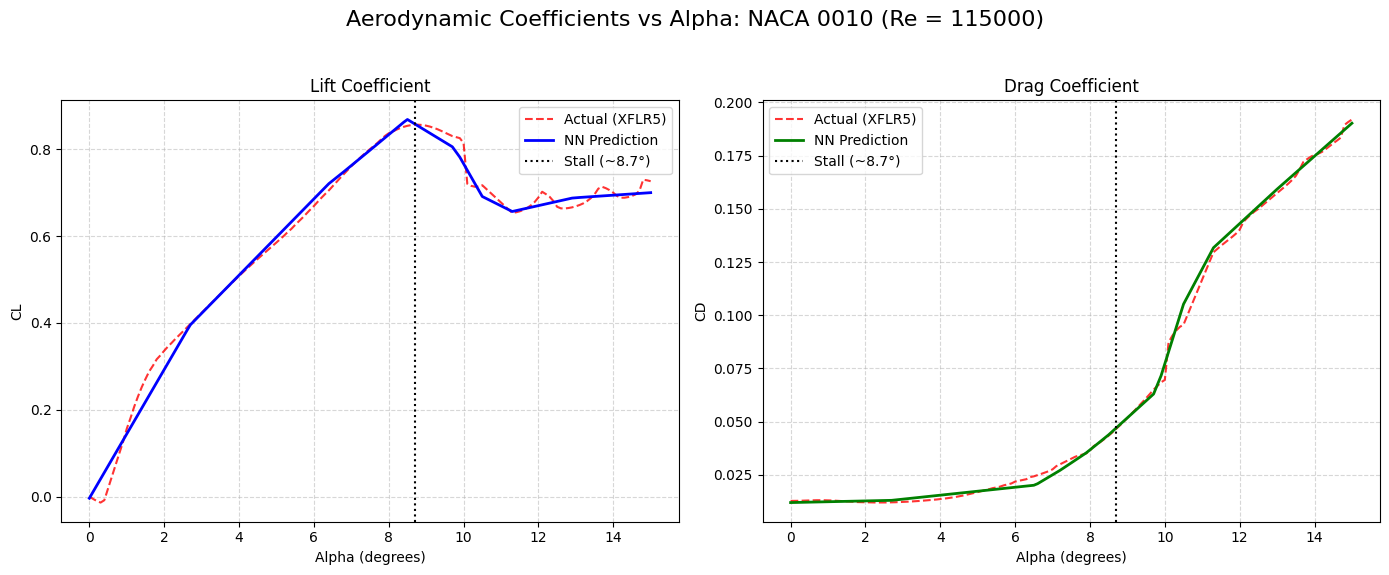


NACA 0010 | Re = 115000
  Pre-stall:
    CL → MAE: 0.0152, MSE: 0.0005, R²: 0.9920
    CD → MAE: 0.0013, MSE: 0.0000, R²: 0.9702
  Post-stall:
    CL → MAE: 0.0150, MSE: 0.0003, R²: 0.9225
    CD → MAE: 0.0019, MSE: 0.0000, R²: 0.9970


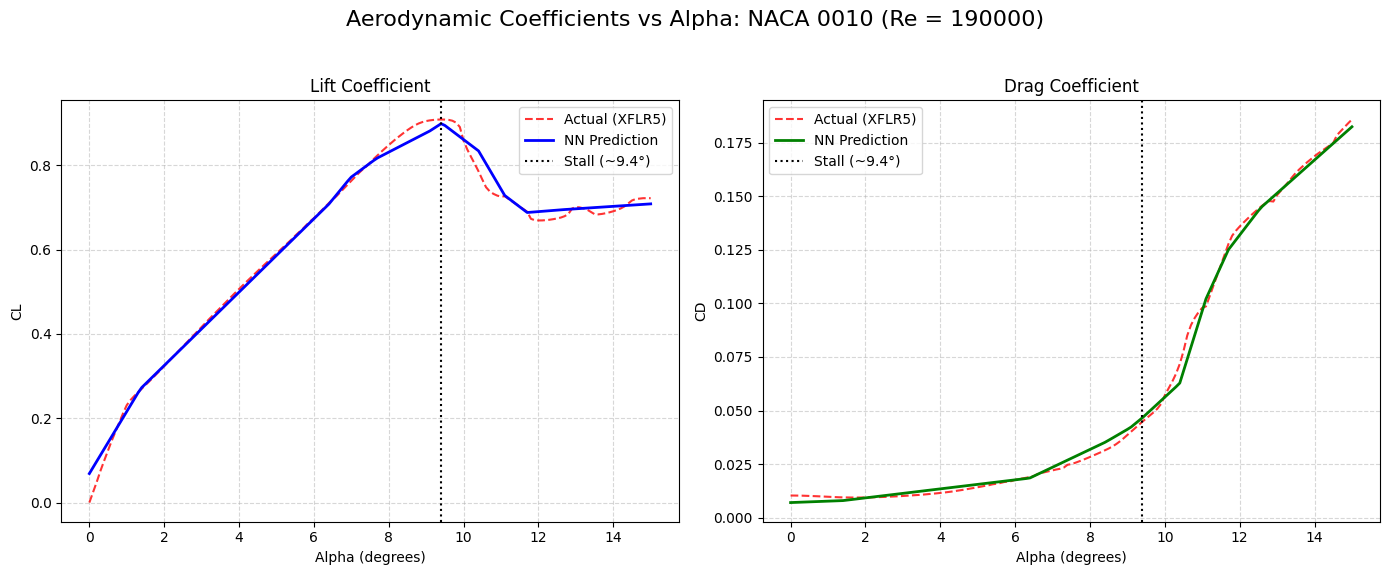


NACA 0010 | Re = 190000
  Pre-stall:
    CL → MAE: 0.0103, MSE: 0.0003, R²: 0.9958
    CD → MAE: 0.0017, MSE: 0.0000, R²: 0.9526
  Post-stall:
    CL → MAE: 0.0180, MSE: 0.0005, R²: 0.8999
    CD → MAE: 0.0028, MSE: 0.0000, R²: 0.9926


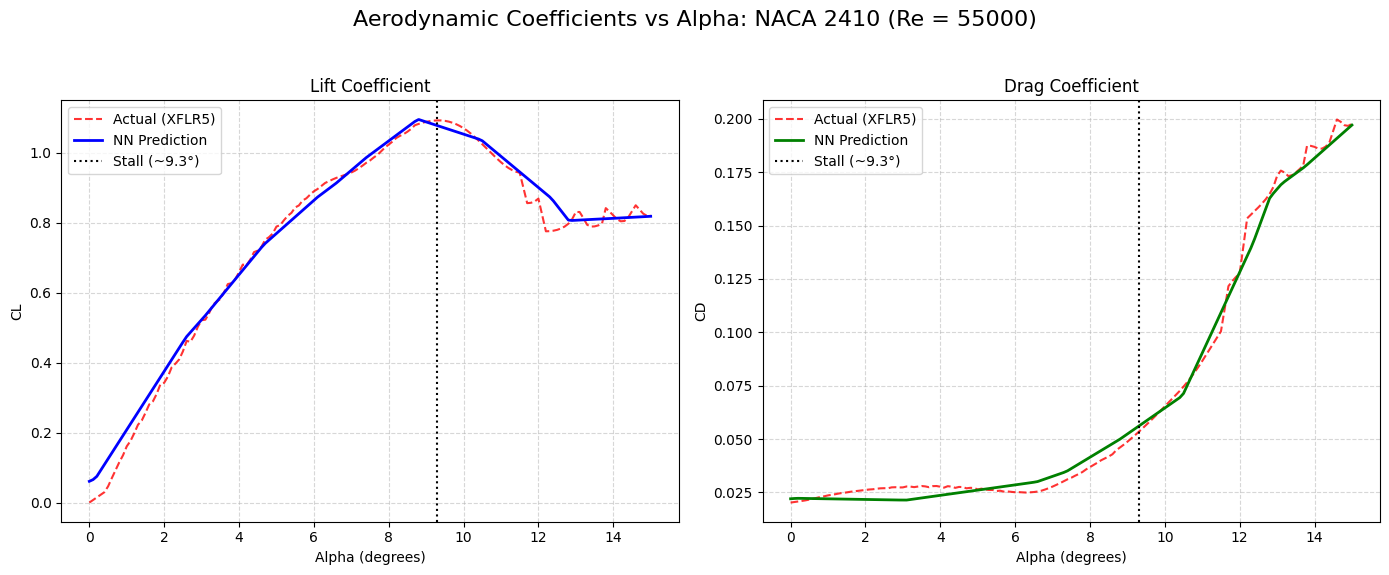


NACA 2410 | Re = 55000
  Pre-stall:
    CL → MAE: 0.0218, MSE: 0.0008, R²: 0.9925
    CD → MAE: 0.0035, MSE: 0.0000, R²: 0.7041
  Post-stall:
    CL → MAE: 0.0234, MSE: 0.0011, R²: 0.9087
    CD → MAE: 0.0040, MSE: 0.0000, R²: 0.9881


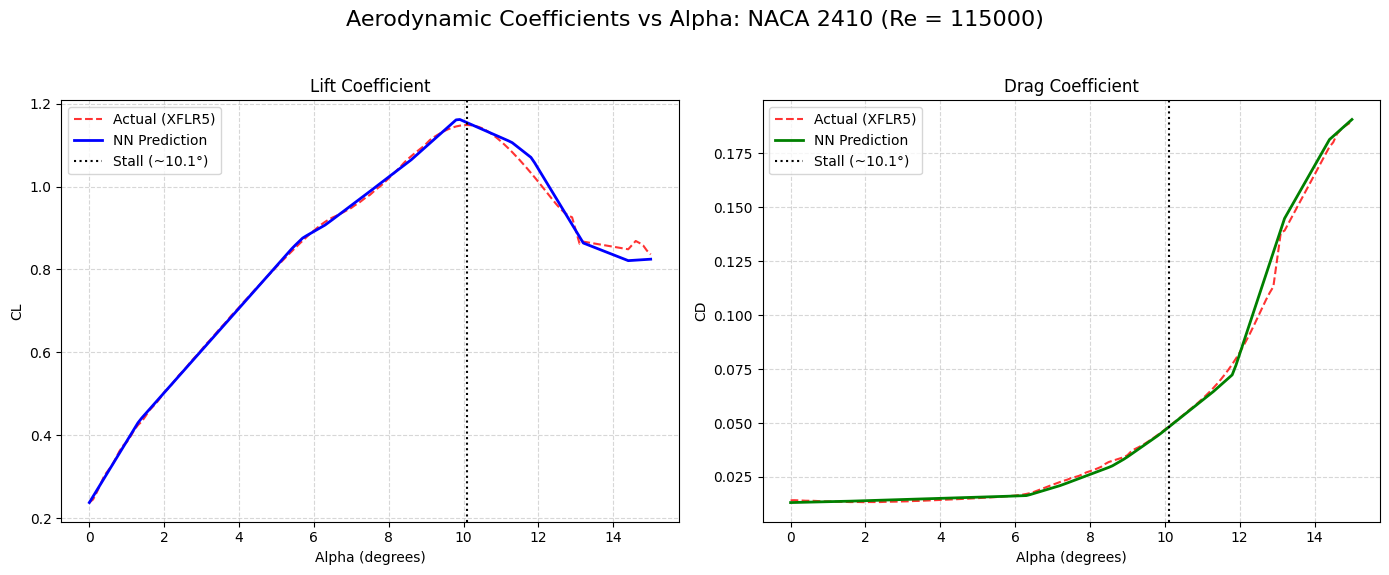


NACA 2410 | Re = 115000
  Pre-stall:
    CL → MAE: 0.0041, MSE: 0.0000, R²: 0.9996
    CD → MAE: 0.0008, MSE: 0.0000, R²: 0.9903
  Post-stall:
    CL → MAE: 0.0183, MSE: 0.0005, R²: 0.9538
    CD → MAE: 0.0033, MSE: 0.0000, R²: 0.9879


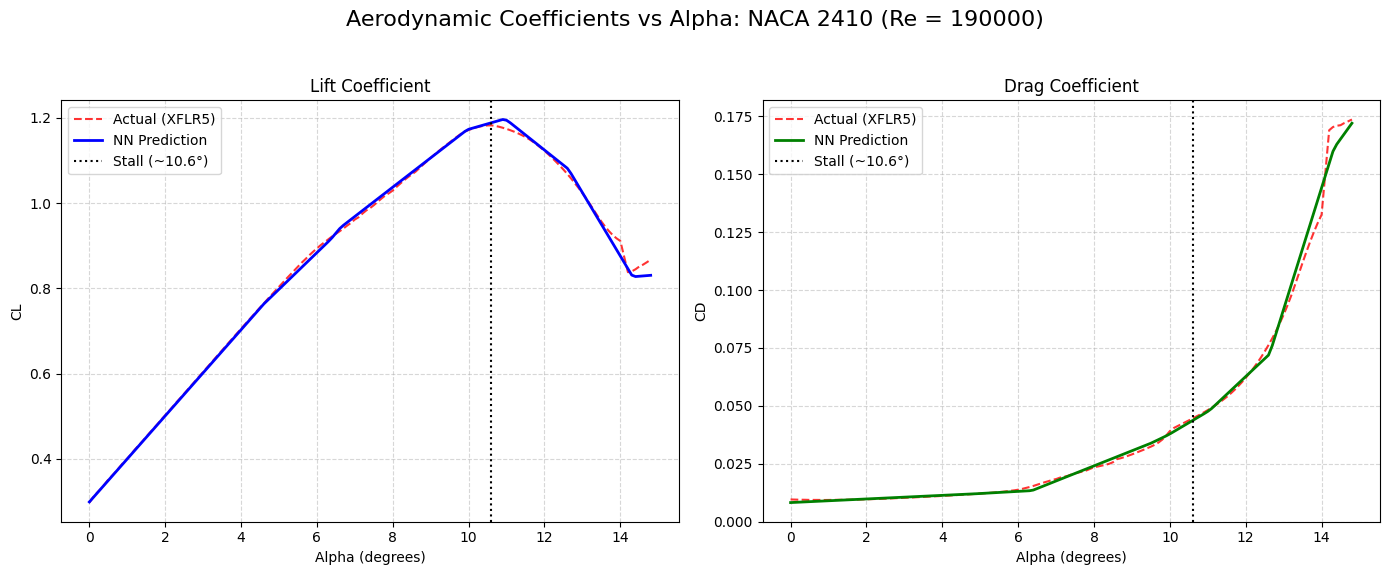


NACA 2410 | Re = 190000
  Pre-stall:
    CL → MAE: 0.0037, MSE: 0.0000, R²: 0.9997
    CD → MAE: 0.0007, MSE: 0.0000, R²: 0.9923
  Post-stall:
    CL → MAE: 0.0115, MSE: 0.0002, R²: 0.9835
    CD → MAE: 0.0036, MSE: 0.0000, R²: 0.9862


In [57]:
test_conditions = [
    ('NACA 0010', 55000),
    ('NACA 0010', 115000),
    ('NACA 0010', 190000),
    ('NACA 2410', 55000),
    ('NACA 2410', 115000),
    ('NACA 2410', 190000),
]

for airfoil, re in test_conditions:
    df_case = df_unseen[(df_unseen['airfoil'] == airfoil) & (df_unseen['Reynolds'] == re)].sort_values('alpha')

    # Build input and predict
    geom   = parse_naca4(airfoil)
    n      = len(df_case)
    X_case = torch.zeros(n, 5)
    X_case[:, 0] = geom[0]
    X_case[:, 1] = geom[1]
    X_case[:, 2] = geom[2]
    X_case[:, 3] = re
    X_case[:, 4] = torch.tensor(df_case['alpha'].values, dtype=torch.float32)

    X_case_s = scale(X_case, X_min, X_max)
    with torch.no_grad():
        Y_case_s = model(X_case_s)
        Y_case   = unscale(Y_case_s, Y_min, Y_max).numpy()

    # Evaluate by region
    stall_angle = df_case.loc[df_case['CL'].idxmax(), 'alpha']
    results = evaluate_by_region(df_case, Y_case, stall_angle)

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Aerodynamic Coefficients vs Alpha: {airfoil} (Re = {re})', fontsize=16)

    # CL
    ax1.plot(df_case['alpha'], df_case['CL'], 'r--', label='Actual (XFLR5)', alpha=0.8)
    ax1.plot(df_case['alpha'], Y_case[:, 0], 'b-', label='NN Prediction', linewidth=2)
    ax1.axvline(x=stall_angle, color='black', linestyle=':', label=f'Stall (~{stall_angle:.1f}°)')
    ax1.set_xlabel('Alpha (degrees)')
    ax1.set_ylabel('CL')
    ax1.set_title('Lift Coefficient')
    ax1.legend()
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)

    # CD
    ax2.plot(df_case['alpha'], df_case['CD'], 'r--', label='Actual (XFLR5)', alpha=0.8)
    ax2.plot(df_case['alpha'], Y_case[:, 1], 'g-', label='NN Prediction', linewidth=2)
    ax2.axvline(x=stall_angle, color='black', linestyle=':', label=f'Stall (~{stall_angle:.1f}°)')
    ax2.set_xlabel('Alpha (degrees)')
    ax2.set_ylabel('CD')
    ax2.set_title('Drag Coefficient')
    ax2.legend()
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print(f"\n{'='*50}")
    print(f"{airfoil} | Re = {re}")
    for region, metrics in results.items():
        print(f"  {region}:")
        print(f"    CL → MAE: {metrics['MAE_CL']:.4f}, MSE: {metrics['MSE_CL']:.4f}, R²: {metrics['R2_CL']:.4f}")
        print(f"    CD → MAE: {metrics['MAE_CD']:.4f}, MSE: {metrics['MSE_CD']:.4f}, R²: {metrics['R2_CD']:.4f}")
